In [1]:
# Check venv matches:
# C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe
import sys
print(sys.executable)

C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe


In [2]:
# imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Make pandas usable for wide MTG data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 0)

In [5]:
# confirm path to data
PROJECT_ROOT = Path("../../..").resolve()
print(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "base"
CARDS_MAIN_PATH = DATA_DIR / "game_features.parquet"
print(CARDS_MAIN_PATH)

# Load parquet to dataframe
cards_main = pd.read_parquet(CARDS_MAIN_PATH)
# Basic shape and schema
print(cards_main.shape)
cards_main.head(5)

C:\Users\mitch\source\repos\mtg_ai
C:\Users\mitch\source\repos\mtg_ai\data\base\game_features.parquet
(33561, 35)


,id,oracle_id,name,mana_cost,cmc,type_line,oracle_text,colors,color_identity,color_indicator,keywords,produced_mana,game_changer,rarity,power,toughness,loyalty,defense,attraction_lights,card_faces,all_parts,legalities,games,rulings_uri,colors_key,color_identity_key,keywords_key,produced_mana_key,card_faces_key,all_parts_key,legalities_key,games_key,supertypes,types,subtypes
0,0000419b-0bba-4488-8f7a-6194544ce91e,b34bb2dc-c1af-4d77-b0b3-a0fb342a5fc6,Forest,,0.0,Basic Land — Forest,({T}: Add {G}.),[],[G],None,[],[G],False,common,None,None,None,None,None,None,"[{'component': 'combo_piece', 'id': 'bddc66f7-4e94-4857-ba7d-6b0083d0bfa0', 'name': 'Forest', 'object': 'related_car...","{'alchemy': 'legal', 'brawl': 'legal', 'commander': 'legal', 'duel': 'legal', 'future': 'legal', 'gladiator': 'legal...","[paper, mtgo, arena]",https://api.scryfall.com/cards/0000419b-0bba-4488-8f7a-6194544ce91e/rulings,[],"[""G""]",[],"[""G""]",None,"[{""component"": ""combo_piece"", ""id"": ""bddc66f7-4e94-4857-ba7d-6b0083d0bfa0"", ""name"": ""Forest"", ""object"": ""related_car...","{""alchemy"": ""legal"", ""brawl"": ""legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""legal"", ""gladiator"": ""legal...","[""paper"", ""mtgo"", ""arena""]",[Basic],[Land],[Forest]
1,0000579f-7b35-4ed3-b44c-db2a538066fe,44623693-51d6-49ad-8cd7-140505caf02f,Fury Sliver,{5}{R},6.0,Creature — Sliver,All Sliver creatures have double strike.,[R],[R],None,[],None,False,uncommon,3,3,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...","[paper, mtgo]",https://api.scryfall.com/cards/0000579f-7b35-4ed3-b44c-db2a538066fe/rulings,"[""R""]","[""R""]",[],None,None,None,"{""alchemy"": ""not_legal"", ""brawl"": ""not_legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladia...","[""paper"", ""mtgo""]",[],[Creature],[Sliver]
2,00006596-1166-4a79-8443-ca9f82e6db4e,8ae3562f-28b7-4462-96ed-be0cf7052ccc,Kor Outfitter,{W}{W},2.0,Creature — Kor Soldier,"When this creature enters, you may attach target Equipment you control to target creature you control.",[W],[W],None,[],None,False,common,2,2,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...","[paper, mtgo]",https://api.scryfall.com/cards/00006596-1166-4a79-8443-ca9f82e6db4e/rulings,"[""W""]","[""W""]",[],None,None,None,"{""alchemy"": ""not_legal"", ""brawl"": ""not_legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladia...","[""paper"", ""mtgo""]",[],[Creature],"[Kor, Soldier]"
3,00009878-d086-46f0-a964-15734d8368ac,30cd69a8-7893-4075-94ca-04450ff821d3,Spirit of the Hearth,{4}{W}{W},6.0,Creature — Cat Spirit,Flying\nYou have hexproof. (You can't be the target of spells or abilities your opponents control.),[W],[W],None,[Flying],None,False,rare,4,5,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",[paper],https://api.scryfall.com/cards/00009878-d086-46f0-a964-15734d8368ac/rulings,"[""W""]","[""W""]","[""Flying""]",None,None,None,"{""alchemy"": ""not_legal"", ""brawl"": ""not_legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladia...","[""paper""]",[],[Creature],"[Cat, Spirit]"
4,0000cd57-91fe-411f-b798-646e965eec37,9f0d82ae-38bf-45d8-8cda-982b6ead1d72,Siren Lookout,{2}{U},3.0,Creature — Siren Pirate,"Flying\nWhen this creature enters, it explores. (Reveal the top card of your library. Put that card into your hand i...",[U],[U],None,"[Flying, Explore]",None,False,common,1,2,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladiator'...","[arena, paper, mtgo]",https://api.scryfall.com/cards/0000cd57-91fe-411f-b798-646e965eec37/rulings,"[""U""]","[""U""]","[""

In [7]:
cards_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33561 entries, 0 to 33560
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  33561 non-null  object
 1   oracle_id           33480 non-null  object
 2   name                33561 non-null  object
 3   mana_cost           32983 non-null  object
 4   cmc                 33480 non-null  object
 5   type_line           33480 non-null  object
 6   oracle_text         32623 non-null  object
 7   colors              32983 non-null  object
 8   color_identity      33561 non-null  object
 9   color_indicator     42 non-null     object
 10  keywords            33561 non-null  object
 11  produced_mana       2613 non-null   object
 12  game_changer        33561 non-null  bool  
 13  rarity              33561 non-null  object
 14  power               18416 non-null  object
 15  toughness           18416 non-null  object
 16  loyalty             31

In [9]:
# cards_main.columns.tolist()

In [10]:
# Unique identifier checks
print(f"Rows: {len(cards_main):,}")
print(f"Unique id: {cards_main['id'].nunique():,}")
print(f"Unique oracle_id: {cards_main['oracle_id'].nunique():,}")
print(f"Duplicate oracle_id rows: {cards_main['oracle_id'].duplicated().sum():,}")
print(f"Duplicate id rows: {cards_main['id'].duplicated().sum():,}")

Rows: 33,561
Unique id: 33,561
Unique oracle_id: 33,480
Duplicate oracle_id rows: 80
Duplicate id rows: 0


In [11]:
# Missing values
missing = cards_main.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

defense              33560
color_indicator      33519
attraction_lights    33511
loyalty              33244
card_faces_key       32623
card_faces           32623
all_parts            31427
all_parts_key        31427
produced_mana        30948
produced_mana_key    30948
toughness            15145
power                15145
oracle_text            938
colors_key             578
mana_cost              578
colors                 578
type_line               81
oracle_id               81
cmc                     81
dtype: int64

In [12]:
# Type-line breakdown checks
type_cols = ["type_line", "supertypes", "types", "subtypes"]

for col in type_cols:
    if col in cards_main.columns:
        print(f"\n--- {col} ---")
        display(cards_main[col].head(10))


--- type_line ---


0                 Basic Land — Forest
1                   Creature — Sliver
2              Creature — Kor Soldier
3               Creature — Cat Spirit
4             Creature — Siren Pirate
5          Creature — Nightmare Drake
6                  Enchantment — Aura
7    Legendary Planeswalker — Chandra
8             Creature — Dryad Shaman
9                   Creature — Zombie
Name: type_line, dtype: object


--- supertypes ---


0        [Basic]
1             []
2             []
3             []
4             []
5             []
6             []
7    [Legendary]
8             []
9             []
Name: supertypes, dtype: object


--- types ---


0            [Land]
1        [Creature]
2        [Creature]
3        [Creature]
4        [Creature]
5        [Creature]
6     [Enchantment]
7    [Planeswalker]
8        [Creature]
9        [Creature]
Name: types, dtype: object


--- subtypes ---


0              [Forest]
1              [Sliver]
2        [Kor, Soldier]
3         [Cat, Spirit]
4       [Siren, Pirate]
5    [Nightmare, Drake]
6                [Aura]
7             [Chandra]
8       [Dryad, Shaman]
9              [Zombie]
Name: subtypes, dtype: object

In [14]:
cards_main["types"].value_counts().head(25)

types
[Creature]                 16974
[Instant]                   3682
[Sorcery]                   3487
[Enchantment]               3442
[Artifact]                  2455
[Land]                      1112
[Planeswalker]               320
[Battle]                      38
[]                             1
[Artifact, Creature]           1
[Enchantment, Artifact]        1
[Artifact, Creature]           1
[Artifact, Creature]           1
[Enchantment, Creature]        1
[Enchantment, Creature]        1
[Artifact, Creature]           1
[Artifact, Creature]           1
[]                             1
[]                             1
[Artifact, Creature]           1
[]                             1
[]                             1
[]                             1
[]                             1
[]                             1
Name: count, dtype: int64

types
Creature        18520
Instant          3833
Artifact         3819
Enchantment      3761
Sorcery          3646
Land             1223
Planeswalker      324
Kindred            78
Battle             38
Name: count, dtype: int64

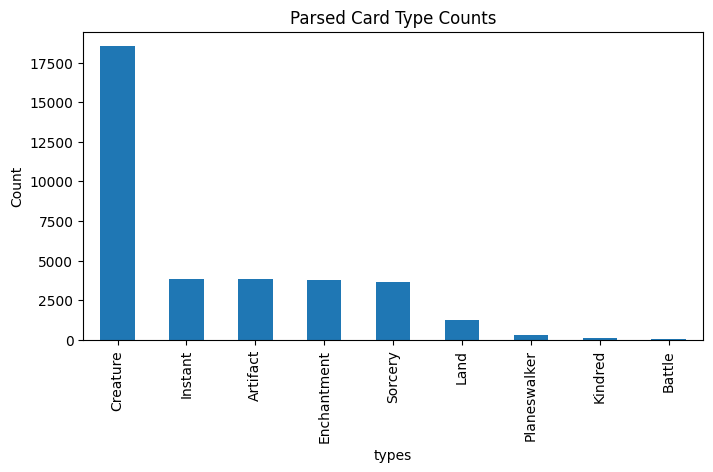

In [15]:
# Explode parsed card types
if "types" in cards_main.columns:
    type_counts = cards_main.explode("types")["types"].value_counts()

    display(type_counts)

    type_counts.plot(kind="bar", figsize=(8, 4))
    plt.title("Parsed Card Type Counts")
    plt.ylabel("Count")
    plt.show()

supertypes
Legendary    4170
Snow          114
World          29
Basic          14
Name: count, dtype: int64

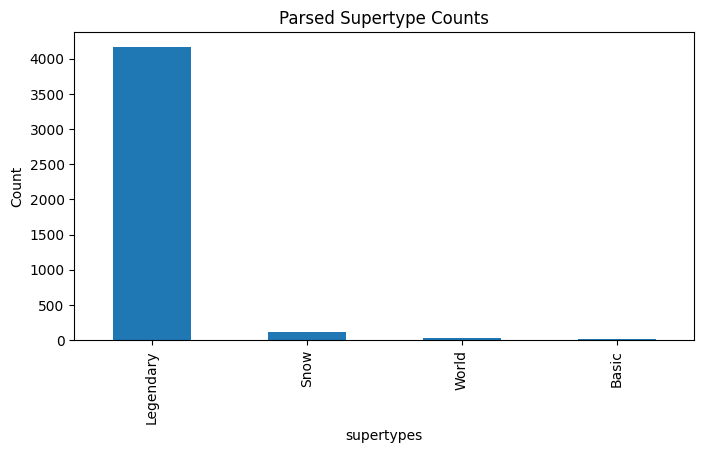

In [16]:
# Explode supertypes
if "supertypes" in cards_main.columns:
    supertype_counts = cards_main.explode("supertypes")["supertypes"].value_counts()

    display(supertype_counts)

    supertype_counts.plot(kind="bar", figsize=(8, 4))
    plt.title("Parsed Supertype Counts")
    plt.ylabel("Count")
    plt.show()

subtypes
Human        4549
Wizard       1292
Aura         1274
Warrior      1270
Soldier      1077
Spirit        728
Elf           715
Cleric        712
Elemental     674
//            636
Zombie        631
Equipment     631
Rogue         627
Goblin        560
Beast         549
Knight        545
—             528
Phyrexian     508
Shaman        506
Bird          470
Vampire       459
Dragon        459
Druid         412
Cat           360
Horror        351
Merfolk       347
Artificer     300
Scout         299
Insect        295
Angel         290
Name: count, dtype: int64

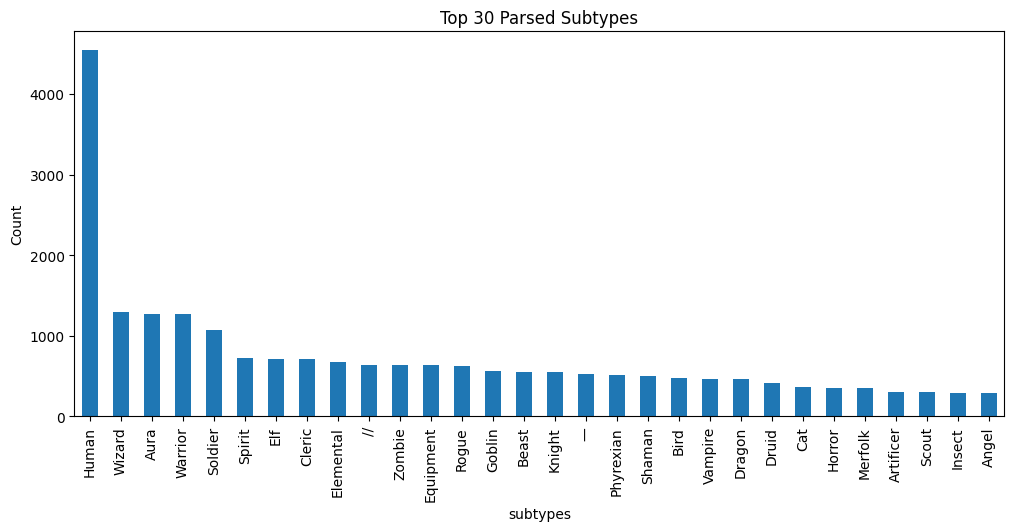

In [17]:
# Top subtypes
if "subtypes" in cards_main.columns:
    subtype_counts = cards_main.explode("subtypes")["subtypes"].value_counts().head(30)

    display(subtype_counts)

    subtype_counts.plot(kind="bar", figsize=(12, 5))
    plt.title("Top 30 Parsed Subtypes")
    plt.ylabel("Count")
    plt.show()

color_identity_display
Colorless    33561
Name: count, dtype: int64

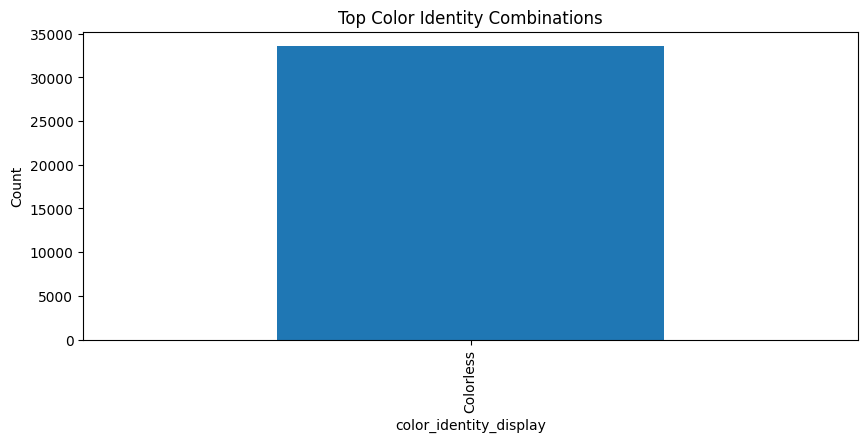

In [18]:
# Color identity check
if "color_identity" in cards_main.columns:
    cards_main["color_identity_display"] = cards_main["color_identity"].apply(
        lambda x: "".join(x) if isinstance(x, list) and len(x) > 0 else "Colorless"
    )

    color_counts = cards_main["color_identity_display"].value_counts()

    display(color_counts.head(20))

    color_counts.head(20).plot(kind="bar", figsize=(10, 4))
    plt.title("Top Color Identity Combinations")
    plt.ylabel("Count")
    plt.show()

In [19]:
# Remaining Token/Card type lines check
token_or_card_mask = cards_main["type_line"].fillna("").str.contains(
    r"\b(?:Token|Card)\b",
    case=False,
    regex=True,
)

print(f"Rows with Token/Card in type_line: {token_or_card_mask.sum():,}")

cards_main.loc[
    token_or_card_mask,
    ["id", "oracle_id", "name", "type_line"]
].head(25)

Rows with Token/Card in type_line: 0


,id,oracle_id,name,type_line


In [20]:
# Complex object coverage
complex_cols = ["card_faces", "all_parts", "legalities", "produced_mana"]

for col in complex_cols:
    if col in cards_main.columns:
        print(f"{col}: {cards_main[col].notna().sum():,} non-null rows")

card_faces: 938 non-null rows
all_parts: 2,134 non-null rows
legalities: 33,561 non-null rows
produced_mana: 2,613 non-null rows


In [21]:
# Sample rows for sanity check
cards_main.sample(10, random_state=42)

,id,oracle_id,name,mana_cost,cmc,type_line,oracle_text,colors,color_identity,color_indicator,keywords,produced_mana,game_changer,rarity,power,toughness,loyalty,defense,attraction_lights,card_faces,all_parts,legalities,games,rulings_uri,colors_key,color_identity_key,keywords_key,produced_mana_key,card_faces_key,all_parts_key,legalities_key,games_key,supertypes,types,subtypes,color_identity_display
573,0046f098-29e8-4659-bcad-39526bf7c6aa,45f159dc-a5f9-4335-896b-ad544c303801,Geistlight Snare,{2}{U},3.0,Instant,This spell costs {1} less to cast if you control a Spirit. It also costs {1} less to cast if you control an enchantm...,[U],[U],None,[],None,False,uncommon,None,None,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladiator'...","[arena, paper, mtgo]",https://api.scryfall.com/cards/0046f098-29e8-4659-bcad-39526bf7c6aa/rulings,"[""U""]","[""U""]",[],None,None,None,"{""alchemy"": ""not_legal"", ""brawl"": ""legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladiator""...","[""arena"", ""paper"", ""mtgo""]",[],[Instant],[],Colorless
29114,39b1bef8-8b30-49e7-a36a-5dc972df50af,8df38d95-1707-4f83-9d64-41f0be2a3b3b,Champion's Victory,{U},1.0,Instant,Cast this spell only during the declare attackers step and only if you've been attacked this step.\nReturn target at...,[U],[U],None,[],None,False,uncommon,None,None,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",[paper],https://api.scryfall.com/cards/39b1bef8-8b30-49e7-a36a-5dc972df50af/rulings,"[""U""]","[""U""]",[],None,None,None,"{""alchemy"": ""not_legal"", ""brawl"": ""not_legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladia...","[""paper""]",[],[Instant],[],Colorless
16253,0dfbdd8f-f336-4945-96d0-2c7246dec7ca,e4b1ef6a-6f05-472e-aaed-1c24dd6605c7,Far // Away,{1}{U} // {2}{B},5.0,Instant // Instant,None,"[B, U]","[B, U]",None,[Fuse],None,False,uncommon,None,None,None,None,None,"[{'artist': 'Greg Staples', 'artist_id': '93d65564-bf00-447b-8406-e2031f03b6b1', 'cmc': None, 'color_indicator': Non...",None,"{'alchemy': 'not_legal', 'brawl': 'legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladiator'...",[arena],https://api.scryfall.com/cards/0dfbdd8f-f336-4945-96d0-2c7246dec7ca/rulings,"[""B"", ""U""]","[""B"", ""U""]","[""Fuse""]",None,"[{""artist"": ""Greg Staples"", ""artist_id"": ""93d65564-bf00-447b-8406-e2031f03b6b1"", ""illustration_id"": ""008f298b-1493-4...",None,"{""alchemy"": ""not_legal"", ""brawl"": ""legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladiator""...","[""arena""]",[],"[Instant, Instant]",[],Colorless
4097,025c83d4-ba5a-4abf-b4ac-33f68de97f7f,f066174a-a959-4365-920f-c04506d94a5a,Spirit en-Kor,{3}{W},4.0,Creature — Kor Spirit,Flying\n{0}: The next 1 damage that would be dealt to this creature this turn is dealt to target creature you contro...,[W],[W],None,[Flying],None,False,common,2,2,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...","[paper, mtgo]",https://api.scryfall.com/cards/025c83d4-ba5a-4abf-b4ac-33f68de97f7f/rulings,"[""W""]","[""W""]","[""Flying""]",None,None,None,"{""alchemy"": ""not_legal"", ""brawl"": ""not_legal"", ""commander"": ""legal"", ""duel"": ""legal"", ""future"": ""not_legal"", ""gladia...","[""paper"", ""mtgo""]",[],[Creature],"[Kor, Spirit]",Colorless
758,0061d4da-28e0-4f95-85cc-e9377a4c8eae,ebdf26a4-77ee-4635-8d52-926bdca623f7,Lux Cannon,{4},4.0,Artifact,"{T}: Put a charge counter on this artifact.\n{T}, Remove three charge counters from this artifact: Destroy target pe...",[],[],None,[],None,False,mythic,None,None,None,None,None,None,None,"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 